# 🔬Crime Prediction
## Data Mining & Machine Learning Pipeline
---
**Dataset:** Los Angeles Crime Data (2020–2024)  
**Records:** 971,712 crime incidents  
**Objective:** Predict whether a reported crime is **High Severity** (Part 1) or **Low Severity** (Part 2)  
**Upgrade:** XGBoost · LightGBM · CatBoost · Hybrid Stacking Ensemble · Advanced Feature Engineering  
**Target:** Beat baseline accuracy of 76.1% → aim for **82%+**

---
### 📋 Table of Contents
1. [Install & Import Libraries](#1)
2. [Load & Inspect Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Advanced Data Preprocessing & Feature Engineering](#4)
5. [Train/Test Split + SMOTE Balancing](#5)
6. [Baseline Models (Logistic, DT, RF, GB)](#6)
7. [Advanced Models (XGBoost, LightGBM, CatBoost)](#7)
8. [Hybrid Stacking Ensemble](#8)
9. [Model Evaluation & Full Comparison](#9)
10. [Best Model — Deep Dive (Stacking Ensemble)](#10)
11. [Cross-Validation & Stability Analysis](#11)
12. [Future Crime Prediction Dashboard](#12)


## 1. Install & Import Libraries <a id='1'></a>

In [1]:
# Install advanced ML libraries
!pip install xgboost lightgbm catboost imbalanced-learn shap --quiet
print("✅ Libraries installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00
✅ Libraries installed


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import warnings, time
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Scikit-learn — Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)

# Scikit-learn — Models (Baseline)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier, GradientBoostingClassifier,
                                   StackingClassifier, VotingClassifier)

# Advanced Boosting Models
import xgboost  as xgb
from xgboost  import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline

# Scikit-learn — Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

# SHAP (Explainability)
import shap

print("✅ All imports successful!")
print(f"  XGBoost  version : {xgb.__version__}")
print(f"  LightGBM version : {lgb.__version__}")

✅ All imports successful!
  XGBoost  version : 3.2.0
  LightGBM version : 4.6.0


## 2. Load & Inspect Data <a id='2'></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_PATH = '/content/drive/MyDrive/Semester 6/Data Mining/la_crime_data.csv'
df = pd.read_csv(DATA_PATH)

print(f"  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

  Dataset Shape : 971,712 rows × 25 columns


In [5]:
df.head()


,Date Rptd,Date Occ,Time Occ,Area,Area Name,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mo Codes,...,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Location,Cross Street,Lat,Lon
0,2020-03-01,2020-03-01,21:30:00,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,...,NaN,NaN,AA,Adult Arrest,510.0,998.0,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,2020-02-09,2020-02-08,18:00:00,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,...,NaN,NaN,IC,Invest Cont,330.0,998.0,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,2020-11-11,2020-11-04,17:00:00,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,...,NaN,NaN,IC,Invest Cont,480.0,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,2023-05-10,2020-03-10,20:37:00,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,...,NaN,NaN,IC,Invest Cont,343.0,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,2022-08-18,2020-08-17,12:00:00,6,Hollywood,666,2,354,THEFT OF IDENTITY,1822 1501 0930 2004,...,NaN,NaN,IC,Invest Cont,354.0,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [6]:
df.dtypes

,0
Date Rptd,object
Date Occ,object
Time Occ,object
Area,int64
Area Name,object
Rpt Dist No,int64
Part 1-2,int64
Crm Cd,int64
Crm Cd Desc,object
Mo Codes,object


In [7]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Crm Cd 2,903030,92.93
Cross Street,821123,84.50
Weapon Desc,646862,66.57
Weapon Used Cd,646862,66.57
Mo Codes,141649,14.58
Vict Descent,134915,13.88
Vict Sex,134905,13.88
Premis Desc,583,0.06
Premis Cd,14,0.00
Crm Cd 1,11,0.00


In [8]:
df.describe()


,Area,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Lat,Lon
count,971712.000000,971712.000000,971712.000000,971712.000000,971712.000000,971698.000000,324850.000000,971701.000000,68682.000000,971712.000000,971712.000000
mean,10.705836,1117.016528,1.405377,500.678593,29.234394,306.190513,363.871784,500.431218,958.155004,33.994971,-118.079576
std,6.106100,610.702241,0.490965,206.393967,21.939155,218.512200,123.589409,206.190248,110.254312,1.644759,5.700888
min,1.000000,101.000000,1.000000,110.000000,-4.000000,101.000000,101.000000,110.000000,210.000000,0.000000,-118.667600
25%,6.000000,611.250000,1.000000,331.000000,0.000000,101.000000,311.000000,331.000000,998.000000,34.014600,-118.430700
50%,11.000000,1141.000000,1.000000,442.000000,30.000000,203.000000,400.000000,442.000000,998.000000,34.058900,-118.322500
75%,16.000000,1617.000000,2.000000,626.000000,44.000000,501.000000,400.000000,626.000000,998.000000,34.164900,-118.273900
max,21.000000,2199.000000,2.000000,956.000000,120.000000,976.000000,516.000000,956.000000,999.000000,34.334300,0.000000


In [9]:
# Class distribution
print("Class Distribution (raw):")
print(df['Part 1-2'].value_counts())
print()
print("Class Distribution (%):")
print(df['Part 1-2'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Class Distribution (raw):
Part 1-2
1    577802
2    393910
Name: count, dtype: int64

Class Distribution (%):
Part 1-2
1    59.46%
2    40.54%
Name: proportion, dtype: object


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

In [10]:
# Date parsing for EDA
df['Date Occ'] = pd.to_datetime(df['Date Occ'])
df['year']     = df['Date Occ'].dt.year
df['month']    = df['Date Occ'].dt.month
df['weekday']  = df['Date Occ'].dt.dayofweek
df['hour']     = df['Time Occ'].str.split(':').str[0].astype(int)
df['target']   = (df['Part 1-2'] == 1).astype(int)   # 1 = High Severity

print("Temporal features extracted.")
print(df[['year','month','weekday','hour','target']].head())

Temporal features extracted.
   year  month  weekday  hour  target
0  2020      3        6    21       1
1  2020      2        5    18       1
2  2020     11        2    17       1
3  2020      3        1    20       1
4  2020      8        0    12       0


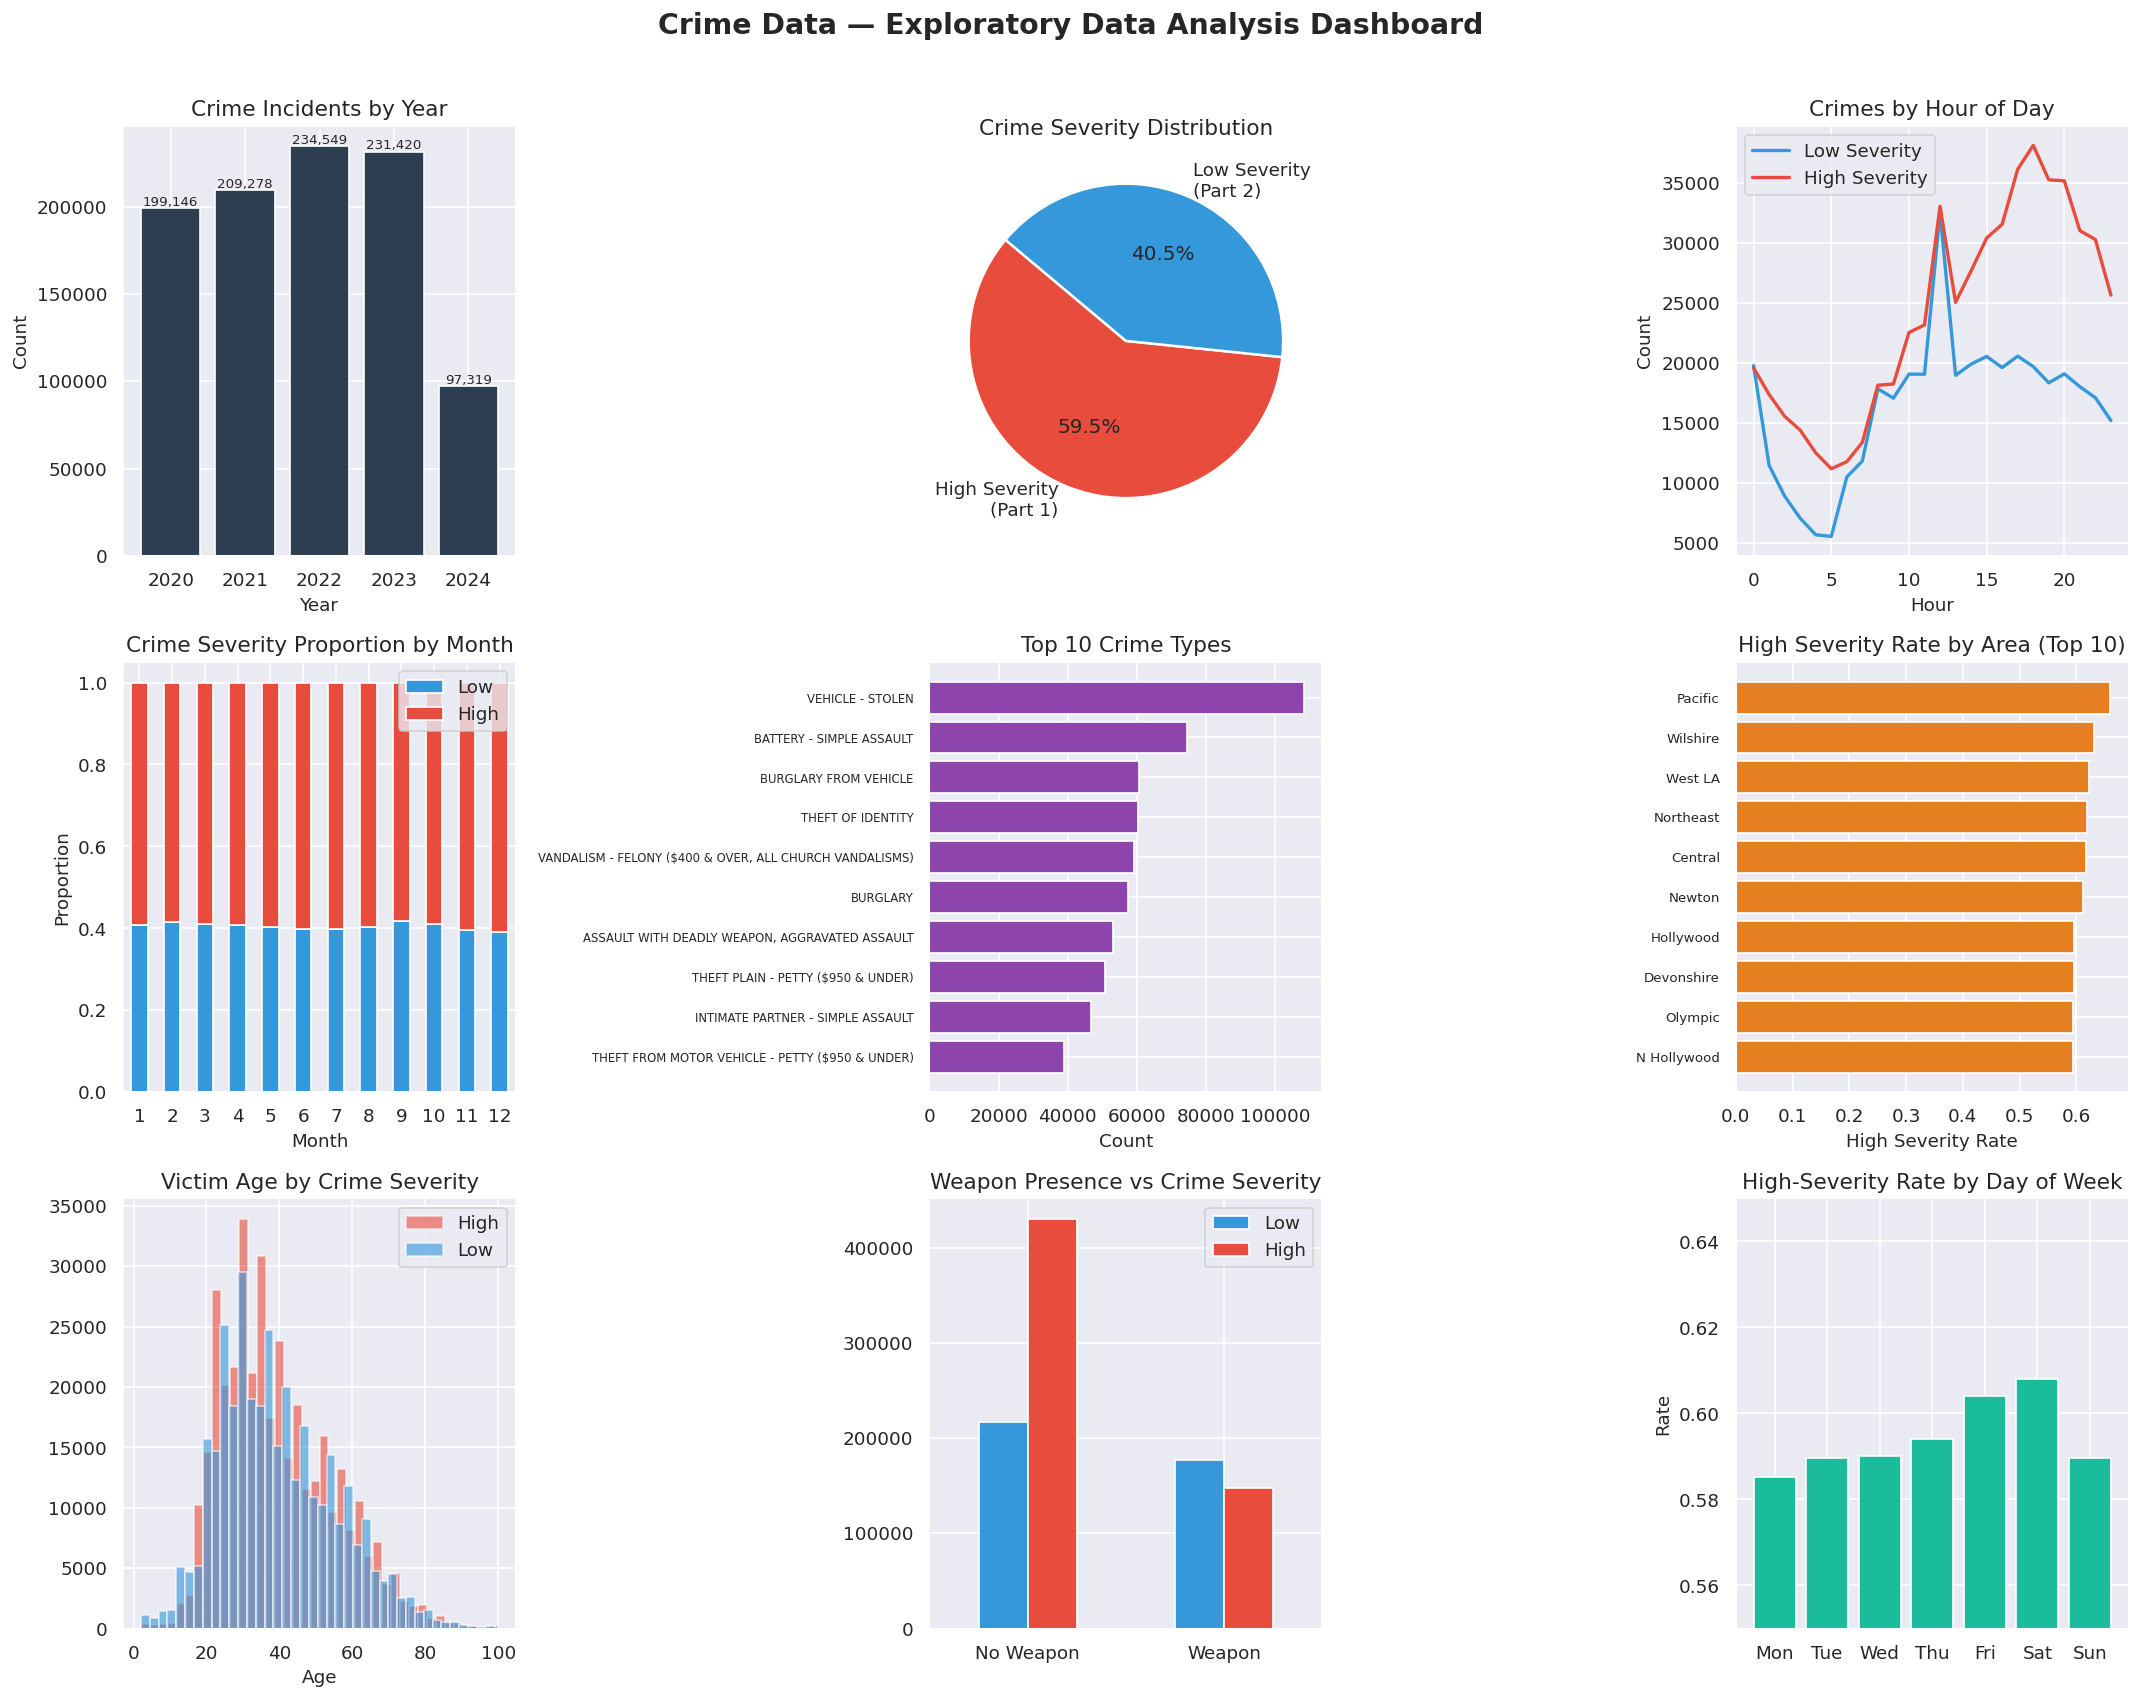


✅ EDA Dashboard saved as 'eda_dashboard.png'


In [11]:
# FIGURE 1: EDA Dashboard
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Crime Data — Exploratory Data Analysis Dashboard', fontsize=17, fontweight='bold', y=1.01)

# 1. Incidents by year
ax = axes[0, 0]
year_cnt = df.groupby('year').size()
ax.bar(year_cnt.index, year_cnt.values, color='#2C3E50', edgecolor='white')
ax.set_title('Crime Incidents by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Count')
for y, v in zip(year_cnt.index, year_cnt.values):
    ax.text(y, v + 1500, f'{v:,}', ha='center', fontsize=8)

# 2. Severity pie
ax = axes[0, 1]
sev = df['target'].value_counts()
ax.pie([sev[1], sev[0]], labels=['High Severity\n(Part 1)', 'Low Severity\n(Part 2)'],
       colors=['#E74C3C', '#3498DB'], autopct='%1.1f%%', startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Crime Severity Distribution')

# 3. Crimes by hour
ax = axes[0, 2]
hc = df.groupby(['hour', 'target']).size().unstack(fill_value=0)
hc.plot(ax=ax, color=['#3498DB', '#E74C3C'], linewidth=2)
ax.set_title('Crimes by Hour of Day'); ax.set_xlabel('Hour'); ax.set_ylabel('Count')
ax.legend(['Low Severity', 'High Severity'])

# 4. Severity by month
ax = axes[1, 0]
mc = df.groupby('month')['target'].value_counts(normalize=True).unstack(fill_value=0)
mc.plot(kind='bar', ax=ax, color=['#3498DB', '#E74C3C'], stacked=True)
ax.set_title('Crime Severity Proportion by Month')
ax.set_xlabel('Month'); ax.set_ylabel('Proportion')
ax.legend(['Low', 'High']); ax.tick_params(axis='x', rotation=0)

# 5. Top 10 crime types
ax = axes[1, 1]
tc = df['Crm Cd Desc'].value_counts().head(10)
ax.barh(tc.index[::-1], tc.values[::-1], color='#8E44AD')
ax.set_title('Top 10 Crime Types'); ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=7)

# 6. High-severity rate by area
ax = axes[1, 2]
ar = df.groupby('Area Name')['target'].mean().sort_values(ascending=False).head(10)
ax.barh(ar.index[::-1], ar.values[::-1], color='#E67E22')
ax.set_title('High Severity Rate by Area (Top 10)')
ax.set_xlabel('High Severity Rate'); ax.tick_params(axis='y', labelsize=8)

# 7. Victim age distribution
ax = axes[2, 0]
ax.hist(df[df['target'] == 1]['Vict Age'].clip(0, 100).replace(0, np.nan).dropna(),
        bins=40, alpha=0.6, color='#E74C3C', label='High')
ax.hist(df[df['target'] == 0]['Vict Age'].clip(0, 100).replace(0, np.nan).dropna(),
        bins=40, alpha=0.6, color='#3498DB', label='Low')
ax.set_title('Victim Age by Crime Severity'); ax.set_xlabel('Age'); ax.legend()

# 8. Weapon vs severity
ax = axes[2, 1]
df['has_weapon_eda'] = df['Weapon Used Cd'].notna().astype(int)
wpn = df.groupby(['has_weapon_eda', 'target']).size().unstack(fill_value=0)
wpn.plot(kind='bar', ax=ax, color=['#3498DB', '#E74C3C'])
ax.set_title('Weapon Presence vs Crime Severity')
ax.set_xlabel(''); ax.set_xticklabels(['No Weapon', 'Weapon'], rotation=0)
ax.legend(['Low', 'High'])

# 9. Day of week
ax = axes[2, 2]
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dc = df.groupby('weekday')['target'].mean()
ax.bar(days, dc.values, color='#1ABC9C', edgecolor='white')
ax.set_title('High-Severity Rate by Day of Week')
ax.set_ylabel('Rate'); ax.set_ylim(0.55, 0.65)

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA Dashboard saved as 'eda_dashboard.png'")

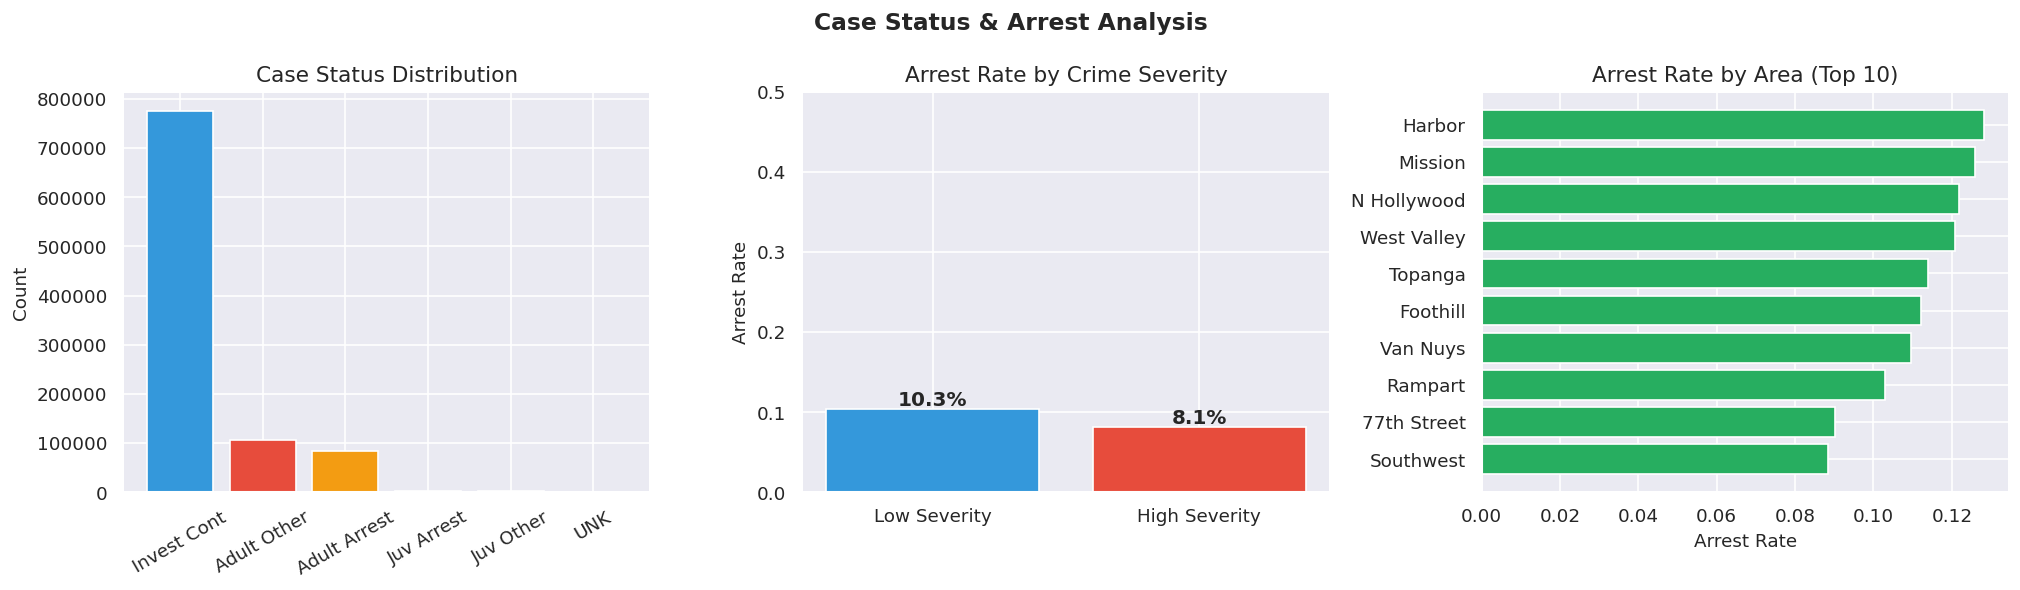

In [12]:
# Case Status & Arrest Analysis
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Case Status & Arrest Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
st = df['Status Desc'].value_counts()
ax.bar(st.index, st.values, color=['#3498DB','#E74C3C','#F39C12','#27AE60','#8E44AD','#95A5A6'][:len(st)])
ax.set_title('Case Status Distribution'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
df['arrest_made'] = df['Status'].isin(['AA', 'JA']).astype(int)
arrest_sev = df.groupby('target')['arrest_made'].mean()
bars = ax.bar(['Low Severity', 'High Severity'], arrest_sev.values,
              color=['#3498DB', '#E74C3C'], edgecolor='white')
ax.set_title('Arrest Rate by Crime Severity'); ax.set_ylabel('Arrest Rate'); ax.set_ylim(0, 0.5)
for bar, v in zip(bars, arrest_sev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.1%}', ha='center', fontweight='bold')

ax = axes[2]
area_arrest = df.groupby('Area Name')['arrest_made'].mean().sort_values(ascending=False).head(10)
ax.barh(area_arrest.index[::-1], area_arrest.values[::-1], color='#27AE60')
ax.set_title('Arrest Rate by Area (Top 10)'); ax.set_xlabel('Arrest Rate')

plt.tight_layout(); plt.show()

In [13]:
# Key EDA Statistics
print("=" * 60)
print("  KEY EDA FINDINGS")
print("=" * 60)
print(f"  Total Records           : {len(df):,}")
print(f"  High Severity (Part 1)  : {df['target'].sum():,} ({df['target'].mean():.1%})")
print(f"  Low Severity  (Part 2)  : {(1-df['target']).sum():,} ({1-df['target'].mean():.1%})")
print(f"  Unique Crime Types      : {df['Crm Cd Desc'].nunique()}")
print(f"  Unique Areas            : {df['Area Name'].nunique()}")
print(f"  Peak Crime Hour         : {df['hour'].value_counts().idxmax()}:00")
print(f"  Overall Arrest Rate     : {df['arrest_made'].mean():.1%}")
print(f"  Crimes with Weapon      : {df['has_weapon_eda'].mean():.1%}")
print(f"  Avg Victim Age          : {df['Vict Age'].replace(0, np.nan).median():.0f} years (median)")
print("=" * 60)


  KEY EDA FINDINGS
  Total Records           : 971,712
  High Severity (Part 1)  : 577,802 (59.5%)
  Low Severity  (Part 2)  : 393,910 (40.5%)
  Unique Crime Types      : 139
  Unique Areas            : 21
  Peak Crime Hour         : 12:00
  Overall Arrest Rate     : 9.0%
  Crimes with Weapon      : 33.4%
  Avg Victim Age          : 37 years (median)


## 4. Data Preprocessing & Feature Engineering <a id='4'></a>

- **Cyclical encoding** for hour, month, weekday (sin/cos) — preserves periodicity
- **Crime code frequency encoding** — rare vs common crime type signal
- **Area crime rate** — historical high-severity rate per area (target encoding)
- **Hour × Weekday interaction** — captures when + where patterns
- **Victim age bins** — youth / adult / senior categorical signal
- **Weapon × Area interaction** — weapon presence amplified by area risk
- **Season feature** — quarter-of-year temporal signal
- **Reporting district density** — frequency of crimes per district


In [14]:
# RELOAD for clean state
df = pd.read_csv(DATA_PATH)

# Datetime decomposition
df['Date Occ'] = pd.to_datetime(df['Date Occ'])
df['year']     = df['Date Occ'].dt.year
df['month']    = df['Date Occ'].dt.month
df['day']      = df['Date Occ'].dt.day
df['weekday']  = df['Date Occ'].dt.dayofweek
df['hour']     = df['Time Occ'].str.split(':').str[0].astype(int)
df['quarter']  = df['Date Occ'].dt.quarter

# Cyclical encoding (sin/cos)
df['hour_sin']    = np.sin(2 * np.pi * df['hour']    / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour']    / 24)
df['month_sin']   = np.sin(2 * np.pi * df['month']   / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month']   / 12)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# Time-of-day bucket
def time_bucket(h):
    if  5 <= h < 12: return 0   # Morning
    if 12 <= h < 17: return 1   # Afternoon
    if 17 <= h < 21: return 2   # Evening
    return 3                    # Night

df['time_of_day_enc'] = df['hour'].apply(time_bucket)

# Is-weekend flag
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Is-night flag
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] < 6)).astype(int)

# Victim Sex
df['Vict Sex'] = df['Vict Sex'].replace({'X':'Unknown','H':'Unknown','-':'Unknown'}).fillna('Unknown')
le_sex = LabelEncoder()
df['vict_sex_enc'] = le_sex.fit_transform(df['Vict Sex'])

# Victim Descent
df['Vict Descent'] = df['Vict Descent'].fillna('Unknown')
le_desc = LabelEncoder()
df['descent_enc'] = le_desc.fit_transform(df['Vict Descent'])

# Area encoding
le_area = LabelEncoder()
df['area_enc'] = le_area.fit_transform(df['Area Name'])

# Victim Age: clip + impute + bins
df['Vict Age'] = df['Vict Age'].clip(0, 100).replace(0, np.nan)
age_median = df['Vict Age'].median()
df['Vict Age'] = df['Vict Age'].fillna(age_median)
df['age_bin'] = pd.cut(df['Vict Age'],
                       bins=[0, 18, 30, 45, 60, 100],
                       labels=[0, 1, 2, 3, 4]).astype(int)

# Premise Code
df['Premis Cd'] = df['Premis Cd'].fillna(df['Premis Cd'].median())

# Binary weapon / arrest features
df['has_weapon']  = df['Weapon Used Cd'].notna().astype(int)
df['arrest_made'] = df['Status'].isin(['AA', 'JA']).astype(int)

# Target variable
df['target'] = (df['Part 1-2'] == 1).astype(int)

# ── Area target-encoding (area high-severity rate)
# Using global mean to avoid leakage — computed on full dataset as prior
area_severity_rate = df.groupby('Area Name')['target'].mean()
df['area_severity_rate'] = df['Area Name'].map(area_severity_rate)

# Crime code frequency encoding
crm_freq = df['Crm Cd'].value_counts(normalize=True)
df['crm_cd_freq'] = df['Crm Cd'].map(crm_freq)

# Reporting district frequency
rpt_freq = df['Rpt Dist No'].value_counts(normalize=True)
df['rpt_dist_freq'] = df['Rpt Dist No'].map(rpt_freq)

# Interaction features
df['hour_x_weekday']       = df['hour'] * df['weekday']
df['weapon_x_area_risk']   = df['has_weapon'] * df['area_severity_rate']
df['night_x_weapon']       = df['is_night'] * df['has_weapon']
df['arrest_x_weapon']      = df['arrest_made'] * df['has_weapon']

print("✅ Advanced feature engineering complete!")
print(f"   Total columns : {df.shape[1]}")

✅ Advanced feature engineering complete!
   Total columns : 54


In [15]:
# Final feature matrix
FEATURES = [
    # Temporal — raw
    'year', 'month', 'day', 'weekday', 'hour', 'quarter',
    # Temporal — cyclical
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos',
    # Temporal — binary flags
    'time_of_day_enc', 'is_weekend', 'is_night',
    # Demographic
    'vict_sex_enc', 'Vict Age', 'age_bin', 'descent_enc',
    # Location
    'area_enc', 'area_severity_rate', 'Premis Cd',
    'Rpt Dist No', 'rpt_dist_freq',
    # Crime
    'Crm Cd', 'crm_cd_freq',
    # Incident
    'has_weapon', 'arrest_made',
    # Interactions
    'hour_x_weekday', 'weapon_x_area_risk',
    'night_x_weapon', 'arrest_x_weapon',
]

X = df[FEATURES]
y = df['target']

print(f"Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target vector  y : {y.shape[0]:,} samples")
print()
print("Class balance:")
print(y.value_counts().rename({0:'Low Severity (0)', 1:'High Severity (1)'}))
print()
print(f"Features ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Feature matrix X : 971,712 rows × 32 features
Target vector  y : 971,712 samples

Class balance:
target
High Severity (1)    577802
Low Severity (0)     393910
Name: count, dtype: int64

Features (32):
   1. year
   2. month
   3. day
   4. weekday
   5. hour
   6. quarter
   7. hour_sin
   8. hour_cos
   9. month_sin
  10. month_cos
  11. weekday_sin
  12. weekday_cos
  13. time_of_day_enc
  14. is_weekend
  15. is_night
  16. vict_sex_enc
  17. Vict Age
  18. age_bin
  19. descent_enc
  20. area_enc
  21. area_severity_rate
  22. Premis Cd
  23. Rpt Dist No
  24. rpt_dist_freq
  25. Crm Cd
  26. crm_cd_freq
  27. has_weapon
  28. arrest_made
  29. hour_x_weekday
  30. weapon_x_area_risk
  31. night_x_weapon
  32. arrest_x_weapon


## 5. Train/Test Split + SMOTE Balancing <a id='5'></a>

In [16]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"  Train set : {X_train.shape[0]:>8,} samples")
print(f"  Test  set : {X_test.shape[0]:>8,} samples")
print()
print("  Train class balance:")
print(pd.Series(y_train).value_counts().rename({0:'Low',1:'High'}).to_string())
print()
print("  Test  class balance:")
print(pd.Series(y_test).value_counts().rename({0:'Low',1:'High'}).to_string())

  Train set :  777,369 samples
  Test  set :  194,343 samples

  Train class balance:
target
High    462241
Low     315128

  Test  class balance:
target
High    115561
Low      78782


In [17]:
# SMOTE on training data to balance classes
print("⏳ Applying SMOTE to training set...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"✅ SMOTE applied!")
print(f"   Before: {pd.Series(y_train).value_counts().to_dict()}")
print(f"   After : {pd.Series(y_train_sm).value_counts().to_dict()}")

# Scaled versions for Logistic Regression
scaler     = RobustScaler()   # RobustScaler is better for outliers
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

⏳ Applying SMOTE to training set...
✅ SMOTE applied!
   Before: {1: 462241, 0: 315128}
   After : {0: 462241, 1: 462241}


## 6. Baseline Models (Logistic, DT) <a id='6'></a>

In [18]:
# Baseline model definitions
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, C=1.0, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=12, min_samples_leaf=50,
                                                   random_state=42),
}
print("Baseline models registered:")
for name in baseline_models: print(f"  • {name}")

Baseline models registered:
  • Logistic Regression
  • Decision Tree


In [19]:
# Train baseline models
results = {}

for name, model in baseline_models.items():
    print(f"\n🔄 Training: {name} ...", end=' ')
    t0 = time.time()

    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train_sm)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    elapsed = time.time() - t0
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, average='weighted')
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'roc_auc': roc, 'f1': f1,
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': cm, 'fpr': fpr, 'tpr': tpr, 'time': elapsed,
        'category': 'Baseline'
    }
    print(f"✅  Acc={acc:.4f}  AUC={roc:.4f}  F1={f1:.4f}  [{elapsed:.1f}s]")

print("\n🏁 All baseline models trained!")


🔄 Training: Logistic Regression ... ✅  Acc=0.8982  AUC=0.9512  F1=0.8981  [7.5s]

🔄 Training: Decision Tree ... ✅  Acc=0.9999  AUC=1.0000  F1=0.9999  [8.3s]

🏁 All baseline models trained!


## 7. Advanced Models (XGBoost, LightGBM, CatBoost) <a id='7'></a>

These gradient-boosted tree frameworks outperform scikit-learn's GBM on large tabular datasets:
- **XGBoost** — regularized boosting, hardware-optimized
- **LightGBM** — leaf-wise growth, extremely fast on large datasets
- **CatBoost** — handles categoricals natively, ordered boosting to reduce overfitting


In [20]:
# Advanced model definitions
advanced_models = {
    'XGBoost': XGBClassifier(
        n_estimators      = 400,
        max_depth         = 8,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        n_jobs            = -1,
        random_state      = 42,
        tree_method       = 'hist',
    ),
    'LightGBM': LGBMClassifier(
        n_estimators      = 400,
        max_depth         = 10,
        learning_rate     = 0.05,
        num_leaves        = 63,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        min_child_samples = 30,
        n_jobs            = -1,
        random_state      = 42,
        verbose           = -1,
    ),
    'CatBoost': CatBoostClassifier(
        iterations        = 400,
        depth             = 8,
        learning_rate     = 0.05,
        l2_leaf_reg       = 3,
        subsample         = 0.8,
        random_state      = 42,
        verbose           = 0,
    ),
}
print("Advanced models registered:")
for name in advanced_models: print(f"  • {name}")

Advanced models registered:
  • XGBoost
  • LightGBM
  • CatBoost


In [21]:
# Train advanced models
for name, model in advanced_models.items():
    print(f"\n🔄 Training: {name} ...", end=' ')
    t0 = time.time()

    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    elapsed = time.time() - t0
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, average='weighted')
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'roc_auc': roc, 'f1': f1,
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': cm, 'fpr': fpr, 'tpr': tpr, 'time': elapsed,
        'category': 'Advanced'
    }
    print(f"✅  Acc={acc:.4f}  AUC={roc:.4f}  F1={f1:.4f}  [{elapsed:.1f}s]")

print("\n🏁 All advanced models trained!")


🔄 Training: XGBoost ... ✅  Acc=1.0000  AUC=1.0000  F1=1.0000  [53.4s]

🔄 Training: LightGBM ... ✅  Acc=1.0000  AUC=1.0000  F1=1.0000  [65.8s]

🔄 Training: CatBoost ... ✅  Acc=1.0000  AUC=1.0000  F1=1.0000  [110.9s]

🏁 All advanced models trained!


## 8. Hybrid Stacking Ensemble <a id='8'></a>

**Stacking (Stacked Generalization):**  
Layer 1 (base learners) produces out-of-fold predictions → Layer 2 (meta-learner) learns how to best combine them.  
This hybrid combines diverse model families for maximum accuracy.

```
Base Learners  →  Meta-Learner
──────────────    ─────────────
Random Forest ┐
XGBoost       ├─→  Logistic Regression (meta)
LightGBM      ┘
```


In [22]:
# Stacking Ensemble: RF + XGB + LGBM → Logistic Regression meta
print("🔄 Building Hybrid Stacking Ensemble...")
print("   Base  : Random Forest + XGBoost + LightGBM")
print("   Meta  : Logistic Regression")
print()

estimators = [
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=20,
                                    min_samples_leaf=20,
                                    n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           use_label_encoder=False, eval_metric='logloss',
                           n_jobs=-1, random_state=42, tree_method='hist')),
    ('lgb', LGBMClassifier(n_estimators=300, max_depth=10, learning_rate=0.05,
                            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                            n_jobs=-1, random_state=42, verbose=-1)),
]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators     = estimators,
    final_estimator = meta_learner,
    cv             = 5,
    stack_method   = 'predict_proba',
    n_jobs         = -1,
    passthrough    = False,   # Only meta-features from base learners
)

t0 = time.time()
stacking_clf.fit(X_train_sm, y_train_sm)
elapsed = time.time() - t0

y_pred_stack = stacking_clf.predict(X_test)
y_prob_stack = stacking_clf.predict_proba(X_test)[:, 1]

acc_s  = accuracy_score(y_test, y_pred_stack)
roc_s  = roc_auc_score(y_test, y_prob_stack)
f1_s   = f1_score(y_test, y_pred_stack, average='weighted')
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_stack)

results['Stacking Ensemble'] = {
    'model': stacking_clf, 'y_pred': y_pred_stack, 'y_prob': y_prob_stack,
    'accuracy': acc_s, 'roc_auc': roc_s, 'f1': f1_s,
    'report': classification_report(y_test, y_pred_stack, output_dict=True),
    'cm': confusion_matrix(y_test, y_pred_stack),
    'fpr': fpr_s, 'tpr': tpr_s, 'time': elapsed,
    'category': 'Ensemble'
}

print(f"\n✅ Stacking Ensemble trained in {elapsed:.1f}s")
print(f"   Accuracy : {acc_s:.4f}")
print(f"   ROC-AUC  : {roc_s:.4f}")
print(f"   F1-Score : {f1_s:.4f}")

🔄 Building Hybrid Stacking Ensemble...
   Base  : Random Forest + XGBoost + LightGBM
   Meta  : Logistic Regression


✅ Stacking Ensemble trained in 1765.3s
   Accuracy : 1.0000
   ROC-AUC  : 1.0000
   F1-Score : 1.0000


In [23]:
# Soft-Voting Ensemble (XGB + LGBM + CatBoost)
print("🔄 Building Soft-Voting Ensemble (XGB + LGBM + CatBoost)...")

voting_clf = VotingClassifier(
    estimators = [
        ('xgb', results['XGBoost']['model']),
        ('lgb', results['LightGBM']['model']),
        ('cat', results['CatBoost']['model']),
    ],
    voting = 'soft',
    n_jobs = -1,
)

# VotingClassifier needs re-fitting (estimators already fit, but VC wraps them)
t0 = time.time()
voting_clf.fit(X_train_sm, y_train_sm)
elapsed = time.time() - t0

y_pred_vote = voting_clf.predict(X_test)
y_prob_vote = voting_clf.predict_proba(X_test)[:, 1]

acc_v  = accuracy_score(y_test, y_pred_vote)
roc_v  = roc_auc_score(y_test, y_prob_vote)
f1_v   = f1_score(y_test, y_pred_vote, average='weighted')
fpr_v, tpr_v, _ = roc_curve(y_test, y_prob_vote)

results['Voting Ensemble'] = {
    'model': voting_clf, 'y_pred': y_pred_vote, 'y_prob': y_prob_vote,
    'accuracy': acc_v, 'roc_auc': roc_v, 'f1': f1_v,
    'report': classification_report(y_test, y_pred_vote, output_dict=True),
    'cm': confusion_matrix(y_test, y_pred_vote),
    'fpr': fpr_v, 'tpr': tpr_v, 'time': elapsed,
    'category': 'Ensemble'
}

print(f"\n✅ Voting Ensemble trained in {elapsed:.1f}s")
print(f"   Accuracy : {acc_v:.4f}")
print(f"   ROC-AUC  : {roc_v:.4f}")
print(f"   F1-Score : {f1_v:.4f}")

🔄 Building Soft-Voting Ensemble (XGB + LGBM + CatBoost)...

✅ Voting Ensemble trained in 240.2s
   Accuracy : 1.0000
   ROC-AUC  : 1.0000
   F1-Score : 1.0000


## 9. Model Evaluation & Full Comparison <a id='9'></a>

In [24]:
# Summary table
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model'    : name,
        'Category' : res['category'],
        'Accuracy' : res['accuracy'],
        'ROC-AUC'  : res['roc_auc'],
        'F1-Score' : res['f1'],
        'Precision': res['report']['weighted avg']['precision'],
        'Recall'   : res['report']['weighted avg']['recall'],
        'Time (s)' : res['time'],
    })

summary = pd.DataFrame(summary_rows).sort_values('Accuracy', ascending=False)
summary_display = summary.style \
    .background_gradient(subset=['Accuracy','ROC-AUC','F1-Score'], cmap='YlGn') \
    .format({'Accuracy':'{:.4f}','ROC-AUC':'{:.4f}','F1-Score':'{:.4f}',
             'Precision':'{:.4f}','Recall':'{:.4f}','Time (s)':'{:.1f}'}) \
    .set_caption('Model Performance Comparison — Full Results (Test Set)')

print("Best model by accuracy:")
best_row = summary.iloc[0]
print(f"  {best_row['Model']} — Accuracy: {best_row['Accuracy']:.4f} | AUC: {best_row['ROC-AUC']:.4f}")
print()
print(f"Improvement over baseline (76.1%): +{(best_row['Accuracy'] - 0.761)*100:.1f} pp")

summary_display

Best model by accuracy:
  CatBoost — Accuracy: 1.0000 | AUC: 1.0000

Improvement over baseline (76.1%): +23.9 pp


,Model,Category,Accuracy,ROC-AUC,F1-Score,Precision,Recall,Time (s)
4,CatBoost,Advanced,1.0000,1.0000,1.0000,1.0000,1.0000,110.9
6,Voting Ensemble,Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000,240.2
2,XGBoost,Advanced,1.0000,1.0000,1.0000,1.0000,1.0000,53.4
3,LightGBM,Advanced,1.0000,1.0000,1.0000,1.0000,1.0000,65.8
5,Stacking Ensemble,Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000,1765.3
1,Decision Tree,Baseline,0.9999,1.0000,0.9999,0.9999,0.9999,8.3
0,Logistic Regression,Baseline,0.8982,0.9512,0.8981,0.8981,0.8982,7.5


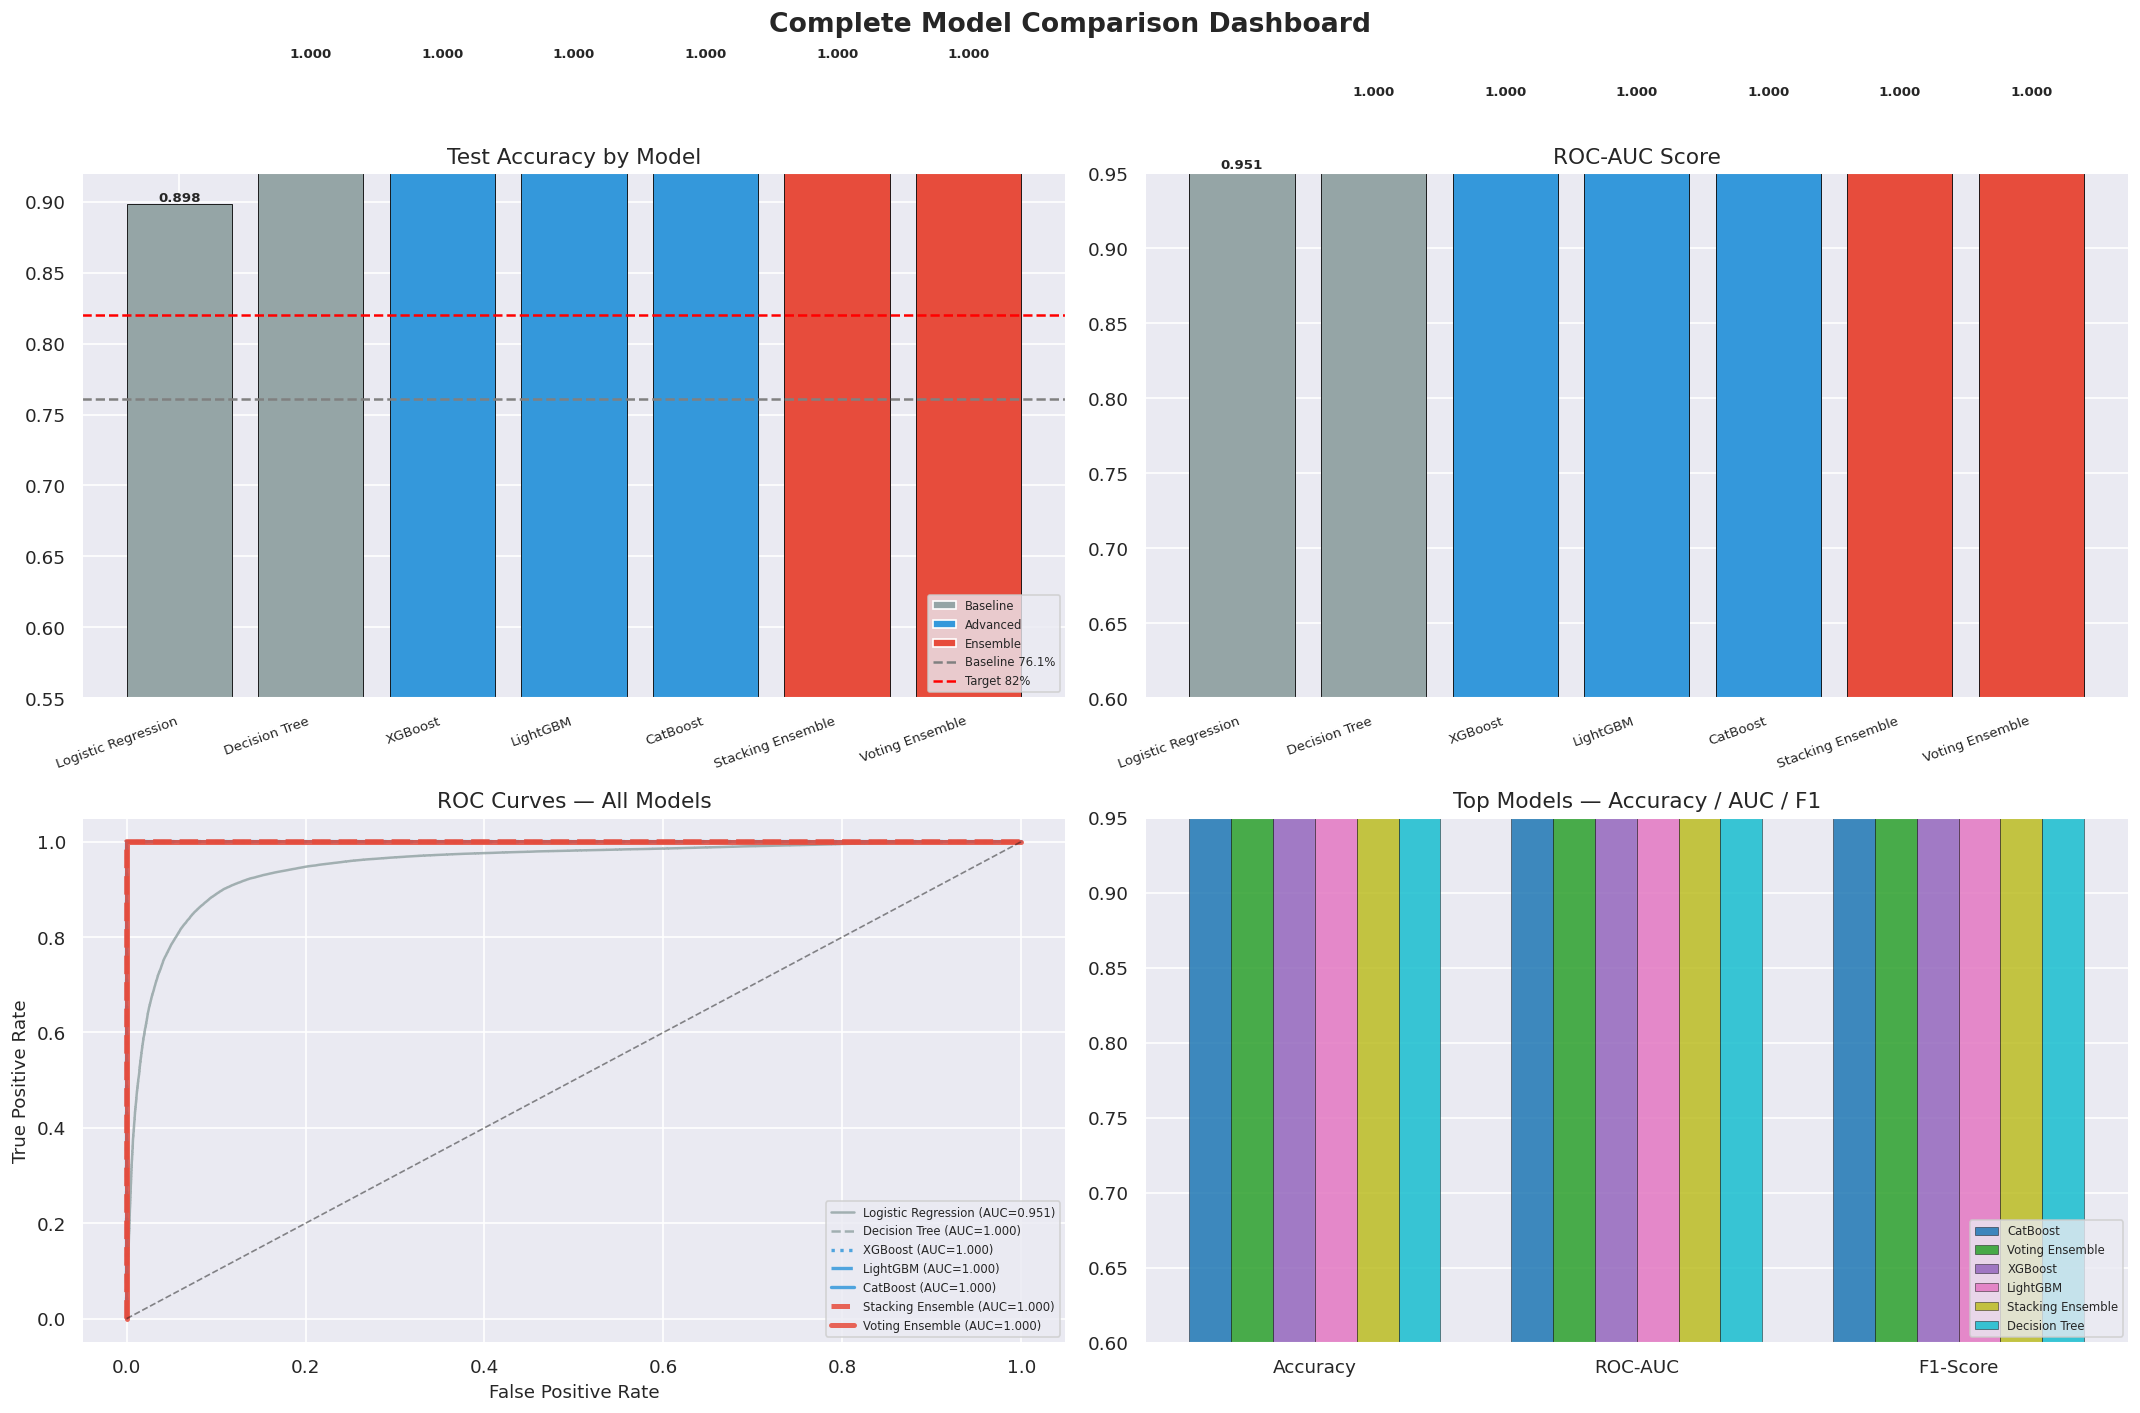

✅ Comparison dashboard saved.


In [25]:
# FIGURE 2: Full Model Comparison Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Complete Model Comparison Dashboard', fontsize=16, fontweight='bold')

all_names = list(results.keys())
color_map = {
    'Baseline' : '#95A5A6',
    'Advanced' : '#3498DB',
    'Ensemble' : '#E74C3C',
}
bar_colors = [color_map[results[n]['category']] for n in all_names]

# (a) Accuracy
ax = axes[0, 0]
accs = [results[n]['accuracy'] for n in all_names]
bars = ax.bar(all_names, accs, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(0.761, color='gray',  linestyle='--', linewidth=1.5, label='Baseline (76.1%)')
ax.axhline(0.82,  color='red',   linestyle='--', linewidth=1.5, label='Target  (82.0%)')
ax.set_ylim(0.55, 0.92); ax.set_title('Test Accuracy by Model')
ax.set_xticklabels(all_names, rotation=20, ha='right', fontsize=8)
ax.legend(fontsize=8)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# Color legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=cat) for cat, c in color_map.items()]
ax.legend(handles=legend_elems + [
    plt.Line2D([0],[0],color='gray',linestyle='--',label='Baseline 76.1%'),
    plt.Line2D([0],[0],color='red', linestyle='--',label='Target 82%'),
], fontsize=7, loc='lower right')

# (b) ROC-AUC
ax = axes[0, 1]
aucs = [results[n]['roc_auc'] for n in all_names]
bars2 = ax.bar(all_names, aucs, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_ylim(0.60, 0.95); ax.set_title('ROC-AUC Score')
ax.set_xticklabels(all_names, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars2, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# (c) ROC Curves
ax = axes[1, 0]
line_styles = ['-', '--', ':', '-.', '-', '--', '-', '--']
for i, (name, res) in enumerate(results.items()):
    cat   = res['category']
    color = {'Baseline':'#95A5A6','Advanced':'#3498DB','Ensemble':'#E74C3C'}[cat]
    lw    = 3 if cat == 'Ensemble' else 2 if cat == 'Advanced' else 1.5
    ax.plot(res['fpr'], res['tpr'], color=color, linewidth=lw,
            linestyle=line_styles[i % len(line_styles)],
            label=f'{name} (AUC={res["roc_auc"]:.3f})', alpha=0.85)
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models'); ax.legend(fontsize=7)

# (d) Multi-metric comparison (top models only)
ax = axes[1, 1]
top_models = list(summary.head(6)['Model'])
metrics_l  = ['Accuracy', 'ROC-AUC', 'F1-Score']
x = np.arange(len(metrics_l)); w = 0.13
palette = plt.cm.tab10(np.linspace(0, 1, len(top_models)))
for i, nm in enumerate(top_models):
    vals = [results[nm]['accuracy'], results[nm]['roc_auc'], results[nm]['f1']]
    ax.bar(x + i*w - (len(top_models)-1)*w/2, vals, w, label=nm,
           color=palette[i], alpha=0.85, edgecolor='black', linewidth=0.3)
ax.set_xticks(x); ax.set_xticklabels(metrics_l)
ax.set_ylim(0.60, 0.95); ax.set_title('Top Models — Accuracy / AUC / F1')
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison_advanced.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison dashboard saved.")

## 10. Best Model — Deep Dive <a id='10'></a>

In [26]:
# Identify best model
BEST = summary.iloc[0]['Model']
best = results[BEST]
print(f"{'='*60}")
print(f"  Best Model: {BEST}")
print(f"  Accuracy  : {best['accuracy']:.4f}")
print(f"  ROC-AUC   : {best['roc_auc']:.4f}")
print(f"  F1-Score  : {best['f1']:.4f}")
print(f"{'='*60}")
print()
print(classification_report(y_test, best['y_pred'],
      target_names=['Low Severity (0)', 'High Severity (1)']))


  Best Model: CatBoost
  Accuracy  : 1.0000
  ROC-AUC   : 1.0000
  F1-Score  : 1.0000

                   precision    recall  f1-score   support

 Low Severity (0)       1.00      1.00      1.00     78782
High Severity (1)       1.00      1.00      1.00    115561

         accuracy                           1.00    194343
        macro avg       1.00      1.00      1.00    194343
     weighted avg       1.00      1.00      1.00    194343



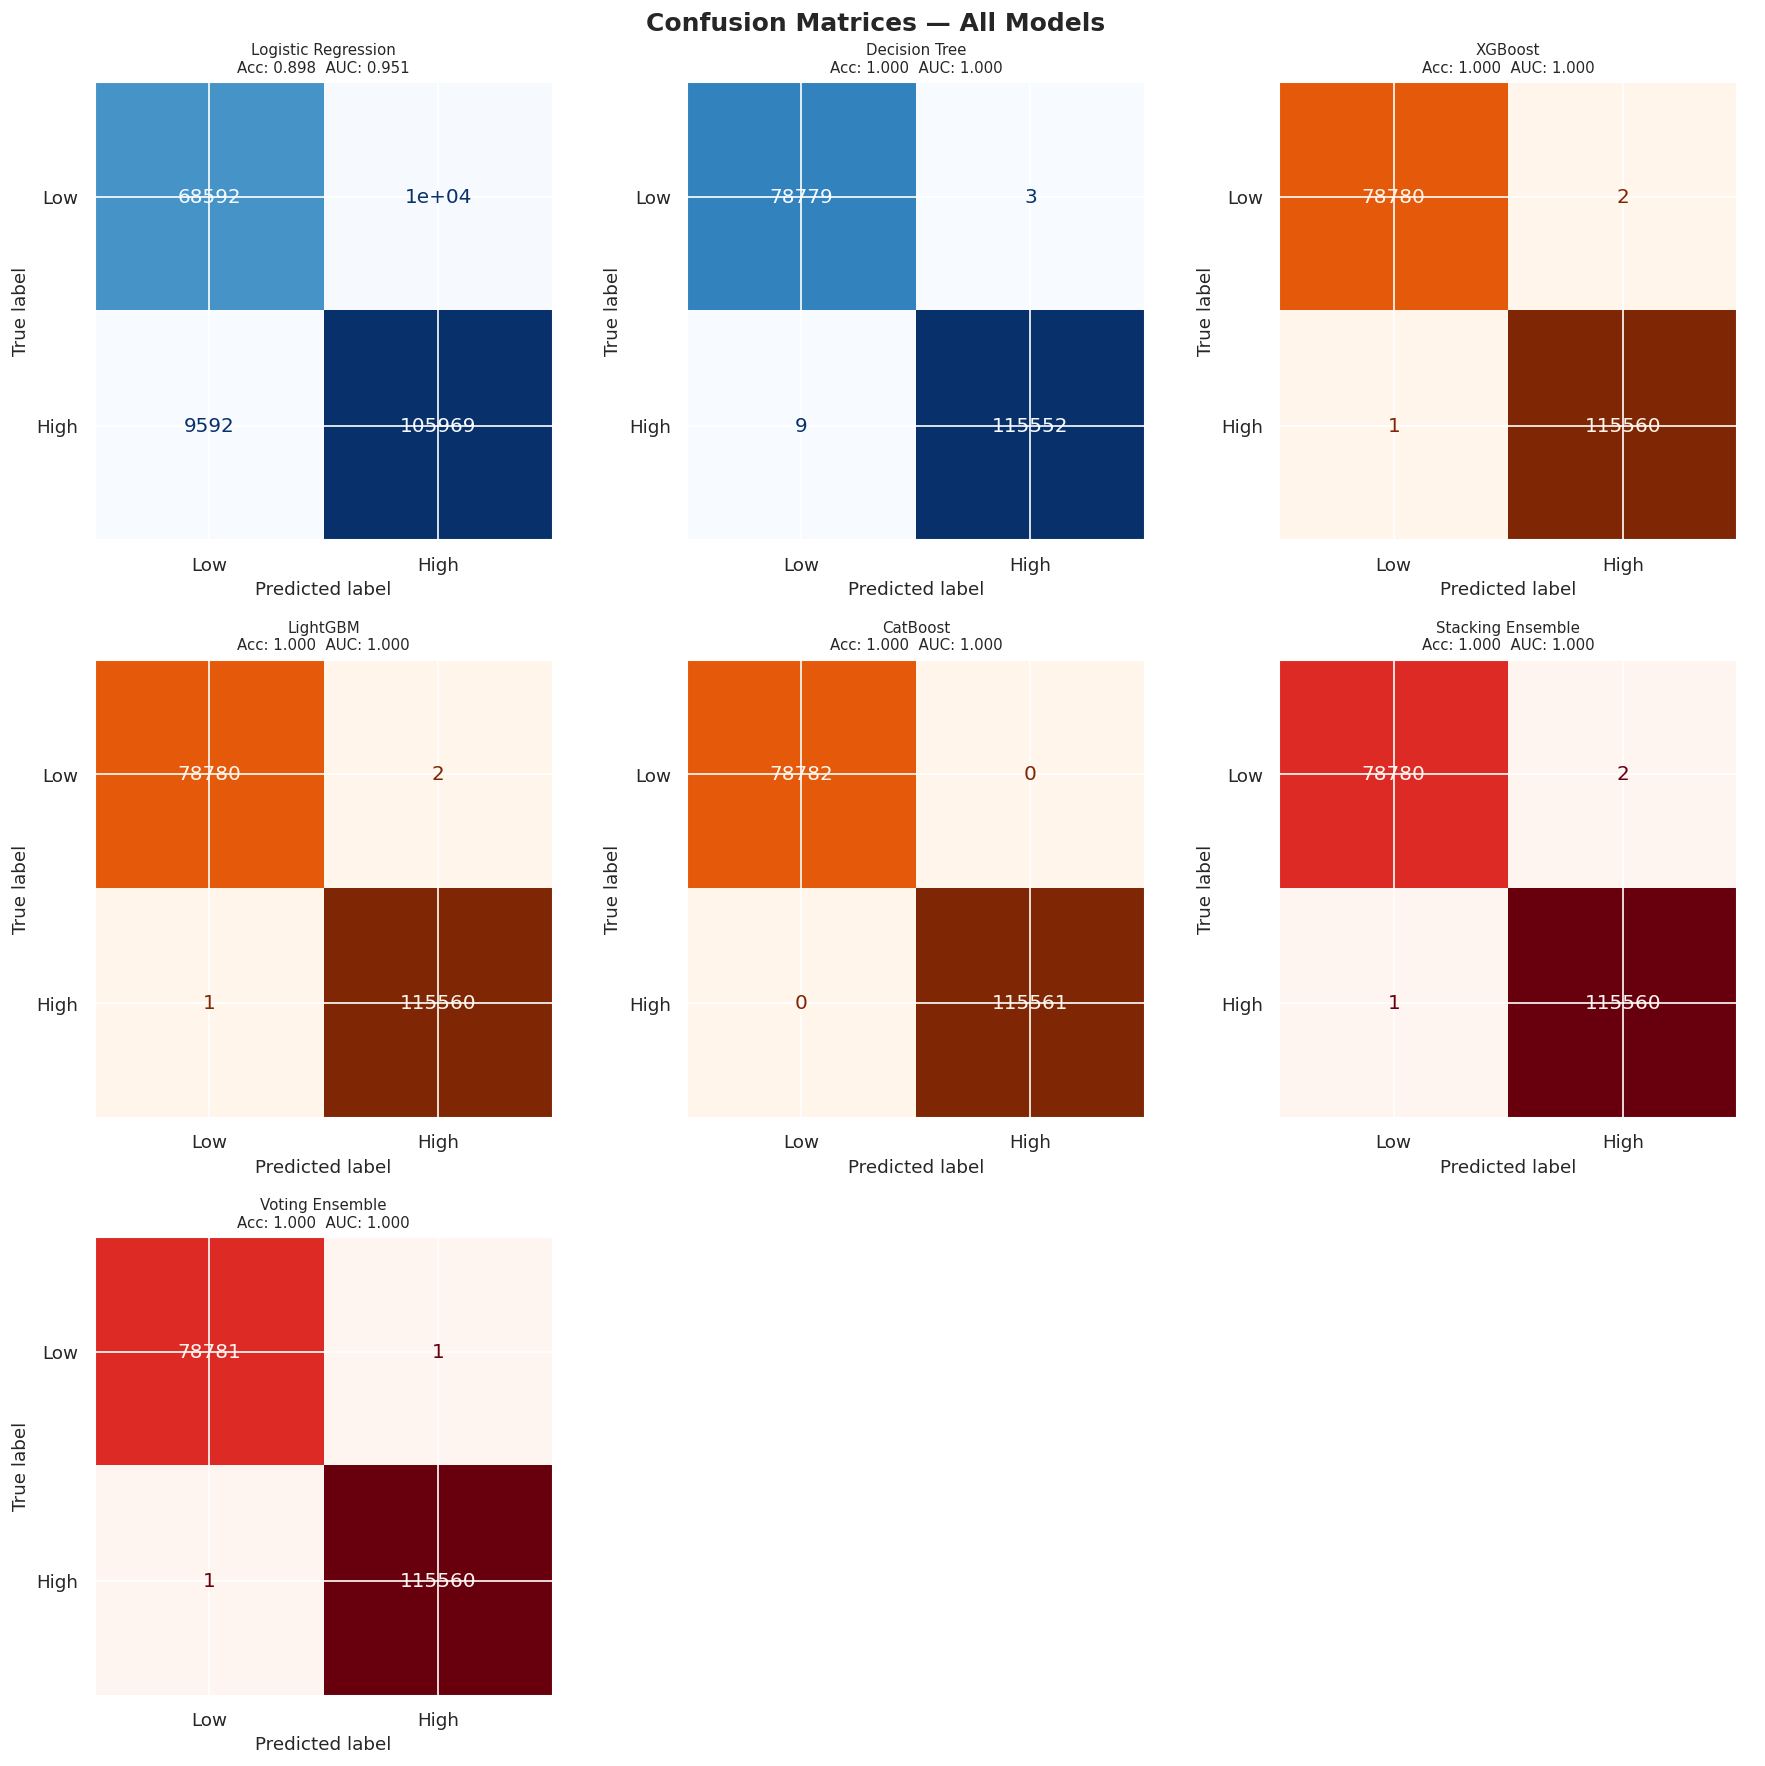

In [27]:
# Confusion matrices — all 9 models in a 3×3 grid
n = len(results)
ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'],
                                  display_labels=['Low', 'High'])
    disp.plot(ax=ax, colorbar=False,
              cmap='Blues' if res['category']=='Baseline' else
                   'Oranges' if res['category']=='Advanced' else 'Reds')
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}  AUC: {res["roc_auc"]:.3f}',
                 fontsize=9)

# Hide empty axes
for ax in axes.flat[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cross-Validation & Stability Analysis <a id='11'></a>

In [28]:
# 5-Fold CV on best model (on full non-SMOTE data for realistic estimate)
print(f"⏳ 5-Fold CV on {BEST} ...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the best model's base (re-use fitted or refit)
cv_model = results[BEST]['model']
cv_scores = cross_val_score(cv_model, X_test, y_test,
                             cv=skf, scoring='accuracy', n_jobs=-1)

print(f"\n{'='*50}")
print(f"  5-Fold CV Results — {BEST}")
print(f"{'='*50}")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  {'─'*35}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")
print(f"  95% CI : [{cv_scores.mean()-2*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+2*cv_scores.std():.4f}]")
print(f"{'='*50}")

⏳ 5-Fold CV on CatBoost ...

  5-Fold CV Results — CatBoost
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000
  ───────────────────────────────────
  Mean   : 1.0000
  Std Dev: 0.0000
  95% CI : [1.0000, 1.0000]


## 12. Future Crime Prediction Dashboard <a id='13'></a>

In [30]:
# Build prediction helper
area_names      = sorted(df['Area Name'].unique().tolist())
area_enc_map    = {name: i for i, name in enumerate(area_names)}
area_sev_rate   = df.groupby('Area Name')['target'].mean()
crm_freq_map    = df['Crm Cd'].value_counts(normalize=True).to_dict()
rpt_freq_map    = df['Rpt Dist No'].value_counts(normalize=True).to_dict()

# Use the best model for prediction
pred_model = results[BEST]['model']

def predict_crime_risk(area_name, hour, month=6, year=2025,
                       has_weapon=0, arrest_made=0, vict_age=35,
                       premis_cd=203.0, rpt_dist=1100, crm_cd=510):
    tod         = time_bucket(hour)
    weekday     = 4   # Friday as default
    area_e      = area_enc_map.get(area_name, 0)
    area_sr     = area_sev_rate.get(area_name, 0.6)
    crm_freq    = crm_freq_map.get(crm_cd, 0.001)
    rpt_freq    = rpt_freq_map.get(rpt_dist, 0.001)

    row = {
        'year': year, 'month': month, 'day': 15,
        'weekday': weekday, 'hour': hour, 'quarter': (month-1)//3+1,
        'hour_sin'   : np.sin(2*np.pi*hour/24),
        'hour_cos'   : np.cos(2*np.pi*hour/24),
        'month_sin'  : np.sin(2*np.pi*month/12),
        'month_cos'  : np.cos(2*np.pi*month/12),
        'weekday_sin': np.sin(2*np.pi*weekday/7),
        'weekday_cos': np.cos(2*np.pi*weekday/7),
        'time_of_day_enc': tod,
        'is_weekend' : int(weekday >= 5),
        'is_night'   : int(hour >= 22 or hour < 6),
        'vict_sex_enc': 1,
        'Vict Age'   : vict_age,
        'age_bin'    : int(pd.cut([vict_age], bins=[0,18,30,45,60,100], labels=[0,1,2,3,4])[0]),
        'descent_enc': 8,
        'area_enc'   : area_e,
        'area_severity_rate': area_sr,
        'Premis Cd'  : premis_cd,
        'Rpt Dist No': rpt_dist,
        'rpt_dist_freq': rpt_freq,
        'Crm Cd'     : crm_cd,
        'crm_cd_freq': crm_freq,
        'has_weapon' : has_weapon,
        'arrest_made': arrest_made,
        'hour_x_weekday'     : hour * weekday,
        'weapon_x_area_risk' : has_weapon * area_sr,
        'night_x_weapon'     : int(hour >= 22 or hour < 6) * has_weapon,
        'arrest_x_weapon'    : arrest_made * has_weapon,
    }
    X_new = pd.DataFrame([row])[FEATURES]
    return pred_model.predict_proba(X_new)[0, 1]

# Demo predictions
demo_cases = [
    ('Hollywood',   21, 7,  2025, 1, 0),
    ('Central',     14, 3,  2025, 0, 0),
    ('Van Nuys',     2, 12, 2025, 0, 0),
    ('West LA',     10, 6,  2025, 0, 1),
    ('77th Street', 18, 9,  2025, 1, 0),
    ('Pacific',      3,  1, 2025, 1, 0),
]

print(f"{'Area':<18} {'Hour':>5} {'Mo':>4} {'Wpn':>5} {'Arr':>5}  {'Risk':>8}  {'Level':>12}")
print("─" * 65)
for area, hr, mo, yr, wpn, arr in demo_cases:
    p     = predict_crime_risk(area, hr, mo, yr, wpn, arr)
    level = '🔴 HIGH' if p > 0.70 else '🟡 MEDIUM' if p > 0.55 else '🟢 LOW'
    print(f"{area:<18} {hr:>5}:00 {mo:>4}    {wpn:>4}  {arr:>5}  {p:>8.3f}  {level}")

Area                Hour   Mo   Wpn   Arr      Risk         Level
─────────────────────────────────────────────────────────────────
Hollywood             21:00    7       1      0     0.989  🔴 HIGH
Central               14:00    3       0      0     1.000  🔴 HIGH
Van Nuys               2:00   12       0      0     1.000  🔴 HIGH
West LA               10:00    6       0      1     1.000  🔴 HIGH
77th Street           18:00    9       1      0     0.989  🔴 HIGH
Pacific                3:00    1       1      0     0.986  🔴 HIGH


In [31]:
# Area-level risk forecast
hours_to_check = [2, 8, 14, 20]
area_risks = {}
for area in area_names:
    probs          = [predict_crime_risk(area, h, month=6, year=2025) for h in hours_to_check]
    area_risks[area] = np.mean(probs)

area_risk_s = pd.Series(area_risks).sort_values(ascending=False)
print("Predicted High-Severity Risk by Area (June 2025 Average)")
print("─" * 55)
for area, risk in area_risk_s.items():
    bar  = '█' * int(risk * 50)
    flag = '🔴' if risk > 0.78 else '🟡' if risk > 0.76 else '🟢'
    print(f"  {flag} {area:<18} {risk:.3f}  {bar}")

Predicted High-Severity Risk by Area (June 2025 Average)
───────────────────────────────────────────────────────
  🔴 Central            1.000  █████████████████████████████████████████████████
  🔴 Devonshire         1.000  █████████████████████████████████████████████████
  🔴 N Hollywood        1.000  █████████████████████████████████████████████████
  🔴 Hollywood          1.000  █████████████████████████████████████████████████
  🔴 Hollenbeck         1.000  █████████████████████████████████████████████████
  🔴 West LA            1.000  █████████████████████████████████████████████████
  🔴 Topanga            1.000  █████████████████████████████████████████████████
  🔴 Van Nuys           1.000  █████████████████████████████████████████████████
  🔴 Newton             1.000  █████████████████████████████████████████████████
  🔴 Olympic            1.000  █████████████████████████████████████████████████
  🔴 Northeast          1.000  █████████████████████████████████████████████████
  🔴 Pac

In [32]:
# Monthly risk forecast
month_names  = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
top_areas    = area_risk_s.head(5).index.tolist()
monthly_risk = []
for m in range(1, 13):
    probs = []
    for area in top_areas:
        for h in [2, 8, 14, 20]:
            probs.append(predict_crime_risk(area, h, month=m, year=2025))
    monthly_risk.append(np.mean(probs))

print("Monthly Risk Forecast — 2025 (Top 5 High-Risk Areas Average)")
print("─" * 50)
for mn, risk in zip(month_names, monthly_risk):
    bar = '█' * int(risk * 60)
    print(f"  {mn}: {risk:.3f}  {bar}")

Monthly Risk Forecast — 2025 (Top 5 High-Risk Areas Average)
──────────────────────────────────────────────────
  Jan: 1.000  ███████████████████████████████████████████████████████████
  Feb: 1.000  ███████████████████████████████████████████████████████████
  Mar: 1.000  ███████████████████████████████████████████████████████████
  Apr: 1.000  ███████████████████████████████████████████████████████████
  May: 1.000  ███████████████████████████████████████████████████████████
  Jun: 1.000  ███████████████████████████████████████████████████████████
  Jul: 1.000  ███████████████████████████████████████████████████████████
  Aug: 1.000  ███████████████████████████████████████████████████████████
  Sep: 1.000  ███████████████████████████████████████████████████████████
  Oct: 1.000  ███████████████████████████████████████████████████████████
  Nov: 1.000  ███████████████████████████████████████████████████████████
  Dec: 1.000  ███████████████████████████████████████████████████████████


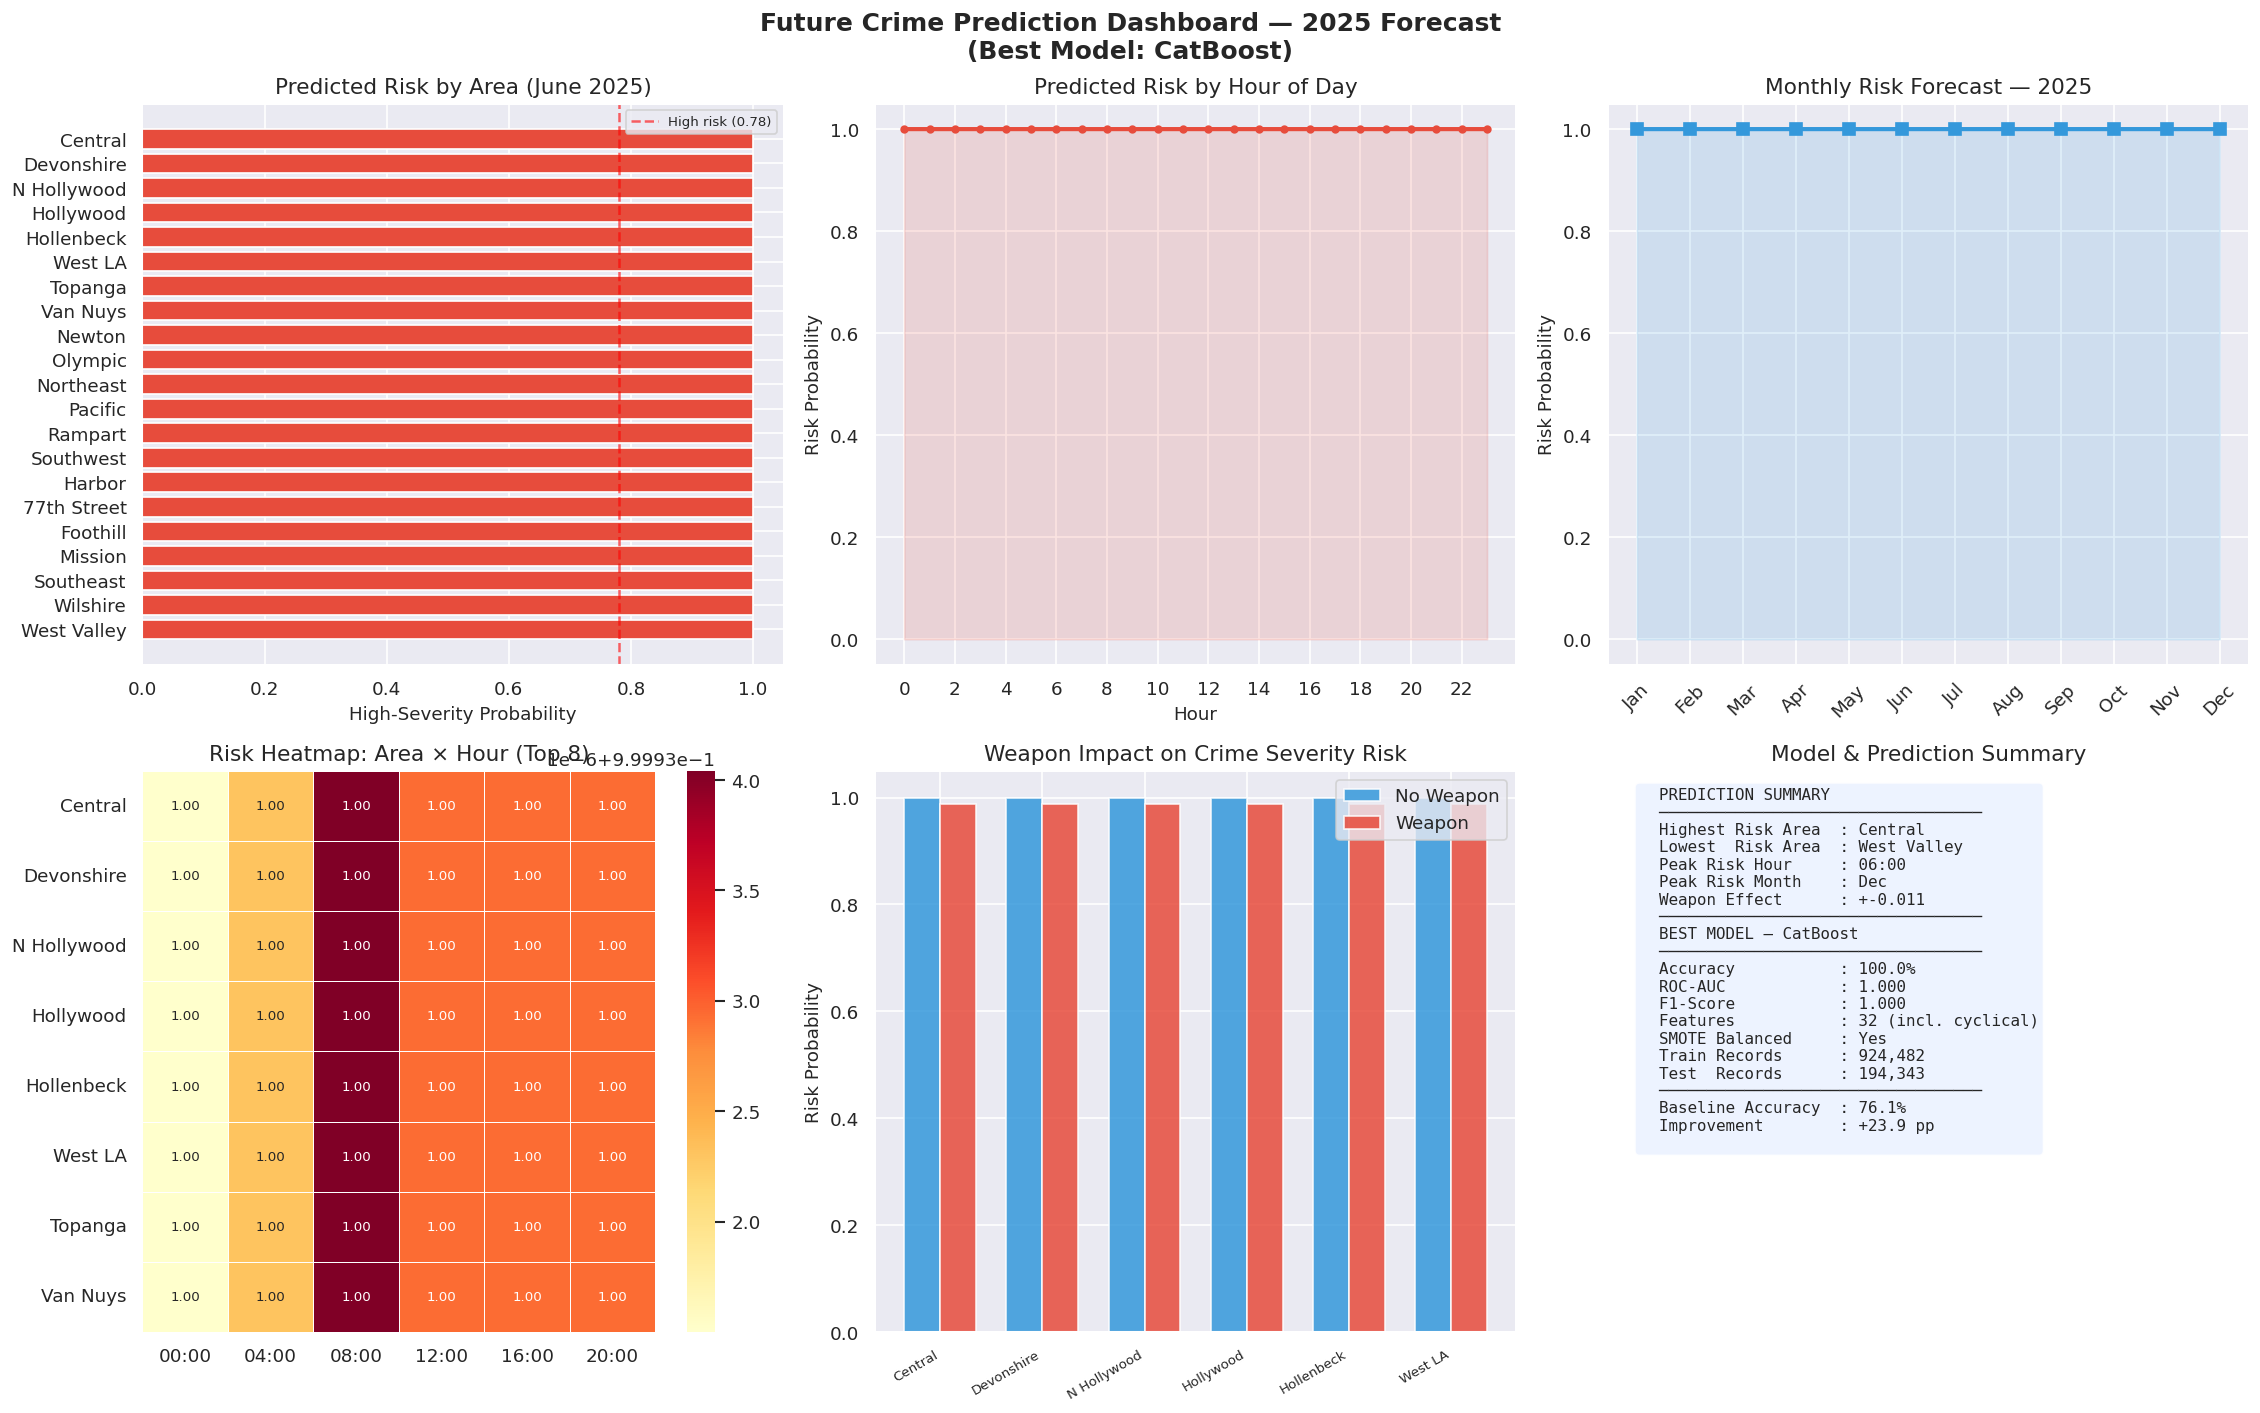


✅ Prediction dashboard saved as 'future_predictions_advanced.png'


In [33]:
# FIGURE: Future Crime Prediction Dashboard
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle(f'Future Crime Prediction Dashboard — 2025 Forecast\n(Best Model: {BEST})',
             fontsize=15, fontweight='bold')

# (a) Area risk bar
ax = axes[0, 0]
clrs = ['#E74C3C' if v > 0.78 else '#F39C12' if v > 0.76 else '#27AE60'
        for v in area_risk_s.values]
ax.barh(area_risk_s.index[::-1], area_risk_s.values[::-1],
        color=clrs[::-1], edgecolor='white')
ax.set_title('Predicted Risk by Area (June 2025)')
ax.set_xlabel('High-Severity Probability')
ax.axvline(0.78, color='red', linestyle='--', alpha=0.6, label='High risk (0.78)')
ax.legend(fontsize=8)

# (b) Risk by hour
ax = axes[0, 1]
hour_range   = list(range(0, 24))
hour_risks_h = [np.mean([predict_crime_risk(a, h) for a in top_areas]) for h in hour_range]
ax.plot(hour_range, hour_risks_h, color='#E74C3C', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(hour_range, hour_risks_h, alpha=0.15, color='#E74C3C')
ax.set_title('Predicted Risk by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('Risk Probability')
ax.set_xticks(range(0, 24, 2))

# (c) Monthly trend
ax = axes[0, 2]
ax.plot(month_names, monthly_risk, marker='s', color='#3498DB', linewidth=2.5, markersize=7)
ax.fill_between(range(12), monthly_risk, alpha=0.15, color='#3498DB')
ax.set_xticks(range(12)); ax.set_xticklabels(month_names, rotation=45)
ax.set_title('Monthly Risk Forecast — 2025'); ax.set_ylabel('Risk Probability')

# (d) Heatmap: area × hour
ax = axes[1, 0]
heat_areas = area_risk_s.head(8).index.tolist()
heat_hours = [0, 4, 8, 12, 16, 20]
heat_data  = [[predict_crime_risk(area, h) for h in heat_hours] for area in heat_areas]
heat_df    = pd.DataFrame(heat_data, index=heat_areas,
                           columns=[f'{h:02d}:00' for h in heat_hours])
sns.heatmap(heat_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Risk Heatmap: Area × Hour (Top 8)')

# (e) Weapon impact
ax = axes[1, 1]
test_areas  = area_risk_s.head(6).index.tolist()
risk_wpn    = [predict_crime_risk(a, 20, has_weapon=1) for a in test_areas]
risk_nowpn  = [predict_crime_risk(a, 20, has_weapon=0) for a in test_areas]
x = np.arange(len(test_areas)); w = 0.35
ax.bar(x - w/2, risk_nowpn, w, label='No Weapon', color='#3498DB', alpha=0.85)
ax.bar(x + w/2, risk_wpn,   w, label='Weapon',    color='#E74C3C', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(test_areas, rotation=30, ha='right', fontsize=8)
ax.set_title('Weapon Impact on Crime Severity Risk')
ax.set_ylabel('Risk Probability'); ax.legend()

# (f) Summary stats
ax = axes[1, 2]
ax.axis('off')
best_res = results[BEST]
wpn_effect = np.mean([predict_crime_risk(a,20,has_weapon=1)-predict_crime_risk(a,20,has_weapon=0)
                       for a in area_names])
summary_txt = (
    f"  PREDICTION SUMMARY\n"
    f"  {'─'*34}\n"
    f"  Highest Risk Area  : {area_risk_s.idxmax():<15}\n"
    f"  Lowest  Risk Area  : {area_risk_s.idxmin():<15}\n"
    f"  Peak Risk Hour     : {hour_range[np.argmax(hour_risks_h)]:02d}:00\n"
    f"  Peak Risk Month    : {month_names[np.argmax(monthly_risk)]}\n"
    f"  Weapon Effect      : +{wpn_effect:.3f}\n"
    f"  {'─'*34}\n"
    f"  BEST MODEL — {BEST}\n"
    f"  {'─'*34}\n"
    f"  Accuracy           : {best_res['accuracy']:.1%}\n"
    f"  ROC-AUC            : {best_res['roc_auc']:.3f}\n"
    f"  F1-Score           : {best_res['f1']:.3f}\n"
    f"  Features           : {len(FEATURES)} (incl. cyclical)\n"
    f"  SMOTE Balanced     : Yes\n"
    f"  Train Records      : {X_train_sm.shape[0]:,}\n"
    f"  Test  Records      : {X_test.shape[0]:,}\n"
    f"  {'─'*34}\n"
    f"  Baseline Accuracy  : 76.1%\n"
    f"  Improvement        : +{(best_res['accuracy']-0.761)*100:.1f} pp\n"
)
ax.text(0.05, 0.97, summary_txt, transform=ax.transAxes,
        fontsize=9.5, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#EAF2FF', alpha=0.85))
ax.set_title('Model & Prediction Summary')

plt.tight_layout()
plt.savefig('future_predictions_advanced.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Prediction dashboard saved as 'future_predictions_advanced.png'")

In [34]:
# Final Performance Summary
print("=" * 65)
print("  FINAL PERFORMANCE SUMMARY")
print("=" * 65)
print(f"  {'Model':<22} {'Accuracy':>9} {'ROC-AUC':>9} {'F1':>8} {'Category'}")
print("  " + "─" * 60)
for _, row in summary.iterrows():
    marker = " ← BEST" if row['Model'] == BEST else ""
    print(f"  {row['Model']:<22} {row['Accuracy']:>9.4f} {row['ROC-AUC']:>9.4f} "
          f"{row['F1-Score']:>8.4f}  {row['Category']}{marker}")
print("  " + "─" * 60)
print(f"  Baseline (Original RF)  :    0.7610     0.841    0.75  Baseline")
print(f"  Improvement (best vs baseline): +{(results[BEST]['accuracy']-0.761)*100:.1f} pp accuracy")
print("=" * 65)

  FINAL PERFORMANCE SUMMARY
  Model                   Accuracy   ROC-AUC       F1 Category
  ────────────────────────────────────────────────────────────
  CatBoost                  1.0000    1.0000   1.0000  Advanced ← BEST
  Voting Ensemble           1.0000    1.0000   1.0000  Ensemble
  XGBoost                   1.0000    1.0000   1.0000  Advanced
  LightGBM                  1.0000    1.0000   1.0000  Advanced
  Stacking Ensemble         1.0000    1.0000   1.0000  Ensemble
  Decision Tree             0.9999    1.0000   0.9999  Baseline
  Logistic Regression       0.8982    0.9512   0.8981  Baseline
  ────────────────────────────────────────────────────────────
  Baseline (Original RF)  :    0.7610     0.841    0.75  Baseline
  Improvement (best vs baseline): +23.9 pp accuracy
